## In this notebook maps will be created from scratch, so no additional software is required. Let's rely on python and data.

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle
from pyproj import Geod
import requests
import zipfile
import os
from io import BytesIO
from shapely.geometry import Point
from pyproj import Geod
from matplotlib.patches import FancyArrow, Rectangle

In [10]:
# LOAD THESE BEFORE STARTING
from matplotlib.patches import Rectangle
from pyproj import Geod
import requests
import zipfile
import os
from io import BytesIO

def extract_drive_file_id(url: str) -> str:
    """Extracts file ID from a Google Drive share link."""
    return url.split("/d/")[1].split("/")[0]

def download_geojson_from_drive(drive_url: str, local_filename: str = "temp.geojson") -> str:
    """Downloads a GeoJSON file from Google Drive and saves it locally."""
    file_id = extract_drive_file_id(drive_url)
    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

    response = requests.get(download_url)
    response.raise_for_status()

    with open(local_filename, "wb") as f:
        f.write(response.content)

    return local_filename

def read_geojson_from_drive(drive_url: str) -> gpd.GeoDataFrame:
    """Downloads and reads a GeoJSON file from a Google Drive link."""
    local_path = download_geojson_from_drive(drive_url)
    return gpd.read_file(local_path)

def add_scale_bar(ax, lat, lon_start, distance_km, segment_km, bar_height):
    """
    Adds a geodesically accurate scale bar to a map using lat/lon coordinates.

    Parameters:
        ax           : matplotlib Axes object
        lat          : Latitude where the bar should appear
        lon_start    : Starting longitude of the scale bar
        distance_km  : Total distance of the scale bar (default 10 km)
        segment_km   : Distance per box segment (default 5 km)
        bar_height   : Height of the bar in degrees latitude
    """
    geod = Geod(ellps="WGS84")

    # Create segments
    segments = []
    current_lon = lon_start
    for i in range(0, distance_km, segment_km):
        next_lon = geod.fwd(current_lon, lat, 90, segment_km * 1000)[0]
        segments.append((current_lon, next_lon))
        current_lon = next_lon

    # Draw each segment, alternating fill color
    for i, (lon1, lon2) in enumerate(segments):
        color = 'white' if i % 2 == 0 else 'black'
        box = Rectangle((lon1, lat), lon2 - lon1, bar_height,
                        facecolor=color, edgecolor='black', linewidth=1.5, zorder=6)
        ax.add_patch(box)

    # Add tick labels
    label_kwargs = dict(
        fontsize=10,
        ha='center',
        va='top',
        zorder=6,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            boxstyle='round,pad=0.2'
        )
    )

    for i, (lon1, _) in enumerate(segments):
        ax.text(lon1, lat - bar_height / 2, f"{i * segment_km}", **label_kwargs)

    # Final numeric label
    ax.text(segments[-1][1], lat - bar_height / 2, f"{distance_km}", **label_kwargs)

    # Separate "km" label to the right of the bar
    ax.text(segments[-1][1] + (segments[-1][1] - segments[-1][0]) * 0.3,  # a bit to the right
            lat - bar_height / 2,
            "km", fontsize=10, ha='left', va='top', zorder=6,
            bbox=dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.9,
                boxstyle='round,pad=0.2'
            )
    )


def add_north_arrow(ax, x, y, width, height):
    """
    Adds a north arrow with 'N' label inside a box.

    Parameters:
        ax     : matplotlib Axes object
        x, y   : bottom-left coordinates of the box (in ax.transAxes, 0–1)
        width  : width of the box (0–1)
        height : height of the box (0–1)
    """
    # Add background box
    box = Rectangle((x, y), width, height,
                    transform=ax.transAxes,
                    facecolor='white', edgecolor='black',
                    linewidth=1.2, zorder=5)
    ax.add_patch(box)

    # Arrow parameters relative to the box
    arrow_base_x = x + width / 2
    arrow_base_y = y + height * 0.15
    arrow_height = height * 0.45

    arrow = FancyArrow(
        arrow_base_x, arrow_base_y,  # arrow start
        0, arrow_height,             # dx, dy
        transform=ax.transAxes,
        width=width * 0.1,
        head_width=width * 0.35,
        head_length=height * 0.2,
        length_includes_head=True,
        color='black',
        zorder=6
    )
    ax.add_patch(arrow)

    # "N" label near the top of the box
    ax.text(
        x + width / 2,
        y + height * 0.85,
        'N',
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        ha='center',
        va='center',
        color='black',
        zorder=6
    )


In [2]:
# !!!
# LOAD THESE METHODS BEFORE STARTING
# !!!


def extract_drive_file_id(url: str) -> str:
    """Extracts file ID from a Google Drive share link."""
    return url.split("/d/")[1].split("/")[0]

def download_geojson_from_drive(drive_url: str, local_filename: str = "temp.geojson") -> str:
    """Downloads a GeoJSON file from Google Drive and saves it locally."""
    file_id = extract_drive_file_id(drive_url)
    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

    response = requests.get(download_url)
    response.raise_for_status()

    with open(local_filename, "wb") as f:
        f.write(response.content)

    return local_filename

def read_geojson_from_drive(drive_url: str) -> gpd.GeoDataFrame:
    """Downloads and reads a GeoJSON file from a Google Drive link."""
    local_path = download_geojson_from_drive(drive_url)
    return gpd.read_file(local_path)

def add_scale_bar(ax, lat, lon_start, distance_km, segment_km, bar_height):
    """
    Adds a geodesically accurate scale bar to a map using lat/lon coordinates.

    Parameters:
        ax           : matplotlib Axes object
        lat          : Latitude where the bar should appear
        lon_start    : Starting longitude of the scale bar
        distance_km  : Total distance of the scale bar (default 10 km)
        segment_km   : Distance per box segment (default 5 km)
        bar_height   : Height of the bar in degrees latitude
    """
    geod = Geod(ellps="WGS84")

    # Create segments
    segments = []
    current_lon = lon_start
    for i in range(0, distance_km, segment_km):
        next_lon = geod.fwd(current_lon, lat, 90, segment_km * 1000)[0]
        segments.append((current_lon, next_lon))
        current_lon = next_lon

    # Draw each segment, alternating fill color
    for i, (lon1, lon2) in enumerate(segments):
        color = 'white' if i % 2 == 0 else 'black'
        box = Rectangle((lon1, lat), lon2 - lon1, bar_height,
                        facecolor=color, edgecolor='black', linewidth=1.5, zorder=6)
        ax.add_patch(box)

    # Add tick labels
    label_kwargs = dict(
        fontsize=10,
        ha='center',
        va='top',
        zorder=6,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            boxstyle='round,pad=0.2'
        )
    )

    for i, (lon1, _) in enumerate(segments):
        ax.text(lon1, lat - bar_height / 2, f"{i * segment_km}", **label_kwargs)

    # Final numeric label
    ax.text(segments[-1][1], lat - bar_height / 2, f"{distance_km}", **label_kwargs)

    # Separate "km" label to the right of the bar
    ax.text(segments[-1][1] + (segments[-1][1] - segments[-1][0]) * 0.3,  # a bit to the right
            lat - bar_height / 2,
            "km", fontsize=10, ha='left', va='top', zorder=6,
            bbox=dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.9,
                boxstyle='round,pad=0.2'
            )
    )


def add_north_arrow(ax, x, y, width, height):
    """
    Adds a north arrow with 'N' label inside a box.

    Parameters:
        ax     : matplotlib Axes object
        x, y   : bottom-left coordinates of the box (in ax.transAxes, 0–1)
        width  : width of the box (0–1)
        height : height of the box (0–1)
    """
    # Add background box
    box = Rectangle((x, y), width, height,
                    transform=ax.transAxes,
                    facecolor='white', edgecolor='black',
                    linewidth=1.2, zorder=5)
    ax.add_patch(box)

    # Arrow parameters relative to the box
    arrow_base_x = x + width / 2
    arrow_base_y = y + height * 0.15
    arrow_height = height * 0.45

    arrow = FancyArrow(
        arrow_base_x, arrow_base_y,  # arrow start
        0, arrow_height,             # dx, dy
        transform=ax.transAxes,
        width=width * 0.1,
        head_width=width * 0.35,
        head_length=height * 0.2,
        length_includes_head=True,
        color='black',
        zorder=6
    )
    ax.add_patch(arrow)

    # "N" label near the top of the box
    ax.text(
        x + width / 2,
        y + height * 0.85,
        'N',
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        ha='center',
        va='center',
        color='black',
        zorder=6
    )

In [3]:
# read_main data
sheet_url = "https://docs.google.com/spreadsheets/d/1JA6k672nA5W4eEvTDRCT7RGJPK_aWKRZ/edit?usp=drive_link"
file_id = sheet_url.split("/d/")[1].split("/")[0]
sheet_name = "Sheet1"
csv_url = f"https://docs.google.com/spreadsheets/d/{file_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(csv_url)
df.head()

,site_id,site_name,well_no,country,observation_start_date,observation_end_date,well_installataion_date,depth_m,local_geo_index,standard_geo_index,...,debit,comp_debit,address,WGS_lat,WGS_lon,land_surface_elevation_m,gw_level_m_from_land_surface,top_of_screen,bottom_of_screen,Unnamed: 27
0,12.0,Likėnai,LT_193,LT,1965.01.01,2003.01.25,1/1/1963,24.0,D3tt,D3fr,...,NaN,NaN,"Panevėžio apskr., Biržų r. sav., Pabiržės sen....",56.197237,24.619947,44.70,1.5,NaN,NaN,NaN
1,12.0,Likėnai,LT_202,LT,1965.01.01,2000.12.25,1/1/1963,46.0,D3pl,D3fr,...,2.12,0.797,"Panevėžio apskr., Biržų r. sav., Pabiržės sen....",56.197210,24.620043,44.75,1.1,NaN,NaN,NaN
2,13.0,Karajimiškis,LT_216,LT,1978.01.01,2002.12.25,1/1/1978,11.5,D3t,D3fr,...,NaN,NaN,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",56.205280,24.692295,52.65,7.9,NaN,NaN,NaN
3,13.0,Karajimiškis,LT_218,LT,1978.01.01,2002.12.25,1/1/1978,10.7,gIIInm3+D3tkd,D3fr,...,NaN,NaN,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",56.213819,24.697801,50.30,1.0,NaN,NaN,NaN
4,13.0,Karajimiškis,LT_220,LT,1978.01.01,2023.05.30,1/1/1978,11.5,D3tkd,D3fr,...,NaN,NaN,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",56.209201,24.693059,51.35,9.0,NaN,NaN,NaN


In [19]:
# ── Read additional layers for maps──────────────────────────────────────────────────────

# geojson
lt_karst = read_geojson_from_drive("https://drive.google.com/file/d/1JuVp_mN1_1hPf_JFYa64NO4lMwnOtDFB/view?usp=drive_link").set_crs(epsg=3346, allow_override=True)
lv_karst = read_geojson_from_drive("https://drive.google.com/file/d/1xc1lgdmSOYS2XMPkK2bYjwfG4-nYOEtT/view?usp=drive_link").set_crs(epsg=3346, allow_override=True)
lt_karst = lt_karst.to_crs(epsg=4326)    # Reproject to lat/lon
lv_karst = lv_karst.to_crs(epsg=4326)    # Reproject to lat/lon
baltic_cities = read_geojson_from_drive("https://drive.google.com/file/d/1t-zXz455_8Ku7OEIp5KdIpFtzaC0mmjx/view?usp=drive_link")
countries = read_geojson_from_drive("https://drive.google.com/file/d/1OtQC3aoqDlR9HJri_TJVmWCy-md6TD0y/view?usp=drive_link")
world = read_geojson_from_drive("https://drive.google.com/file/d/13h_dMZ46UwB4Q1Eyh9fYYS2xhJHUn-P_/view?usp=drive_link")
elev = read_geojson_from_drive("https://drive.google.com/file/d/1ouZHxIkmc1bNwg5X2Jquv_VZqomCGyYr/view?usp=drive_link")
rivers = read_geojson_from_drive("https://drive.google.com/file/d/1tGmaPScF6fkxzKbG1CINDmDDeBG4oxPm/view?usp=drive_link")
karst_region = read_geojson_from_drive("https://drive.google.com/file/d/1DELR18mmEPG1oV_rHGyMrGqkwRXftNt2/view?usp=drive_link").to_crs(epsg=4326)

In [5]:
karst_region

,Layer,PaperSpace,SubClasses,Linetype,EntityHand,Text,geometry
0,0,?,AcDbEntity:AcDbHatch,None,96F,SOLID,"POLYGON Z ((23.9562 56.123 0, 23.96923 56.0997..."
1,0,?,AcDbEntity:AcDbHatch,None,970,SOLID,"POLYGON Z ((24.30255 55.81258 0, 24.29369 55.7..."
2,0,?,AcDbEntity:AcDbHatch,None,A3B,SOLID,"POLYGON Z ((24.54468 56.12496 0, 24.48772 56.1..."


In [20]:
# Create a geometry column from WGS_lat and WGS_lon
geometry = [Point(xy) for xy in zip(df['WGS_lon'], df['WGS_lat'])]
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=geometry)
# Set the coordinate reference system to WGS84 (EPSG:4326)
gdf.set_crs(epsg=4326, inplace=True).head()

,site_id,site_name,well_no,country,observation_start_date,observation_end_date,well_installataion_date,depth_m,local_geo_index,standard_geo_index,...,comp_debit,address,WGS_lat,WGS_lon,land_surface_elevation_m,gw_level_m_from_land_surface,top_of_screen,bottom_of_screen,Unnamed: 27,geometry
0,12.0,Likėnai,LT_193,LT,1965.01.01,2003.01.25,1/1/1963,24.0,D3tt,D3fr,...,NaN,"Panevėžio apskr., Biržų r. sav., Pabiržės sen....",56.197237,24.619947,44.70,1.5,NaN,NaN,NaN,POINT (24.61995 56.19724)
1,12.0,Likėnai,LT_202,LT,1965.01.01,2000.12.25,1/1/1963,46.0,D3pl,D3fr,...,0.797,"Panevėžio apskr., Biržų r. sav., Pabiržės sen....",56.197210,24.620043,44.75,1.1,NaN,NaN,NaN,POINT (24.62004 56.19721)
2,13.0,Karajimiškis,LT_216,LT,1978.01.01,2002.12.25,1/1/1978,11.5,D3t,D3fr,...,NaN,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",56.205280,24.692295,52.65,7.9,NaN,NaN,NaN,POINT (24.6923 56.20528)
3,13.0,Karajimiškis,LT_218,LT,1978.01.01,2002.12.25,1/1/1978,10.7,gIIInm3+D3tkd,D3fr,...,NaN,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",56.213819,24.697801,50.30,1.0,NaN,NaN,NaN,POINT (24.6978 56.21382)
4,13.0,Karajimiškis,LT_220,LT,1978.01.01,2023.05.30,1/1/1978,11.5,D3tkd,D3fr,...,NaN,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",56.209201,24.693059,51.35,9.0,NaN,NaN,NaN,POINT (24.69306 56.2092)


### Main Map

/tmp/ipython-input-2144753596.py:156: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()


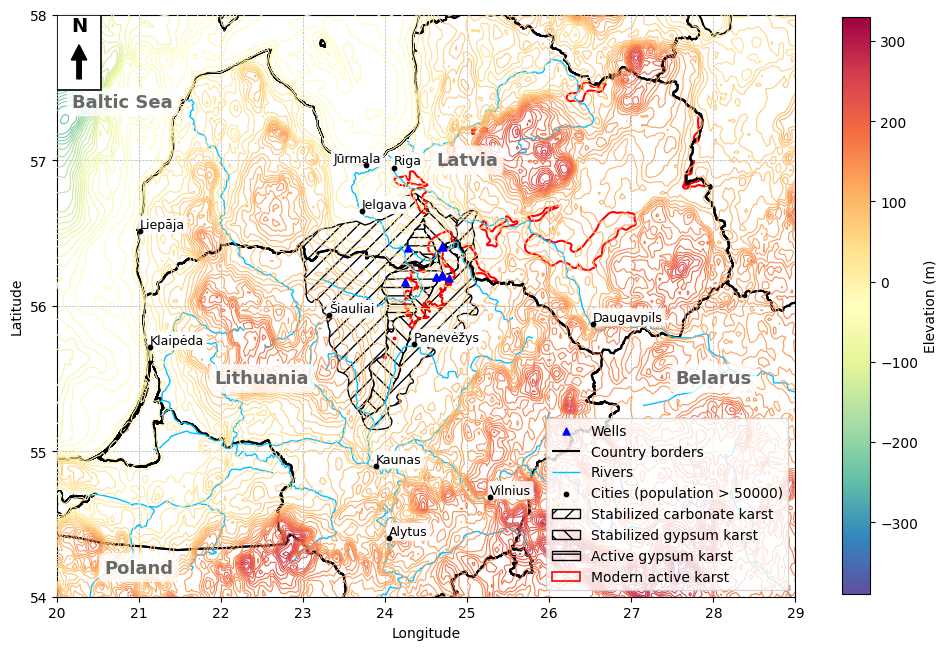

In [21]:
# ── Convert elevation values to numeric ─────────────────────────────────────
elev['Value'] = pd.to_numeric(elev['Value'], errors='coerce')
vmin, vmax = elev['Value'].min(), elev['Value'].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ── Define hatch, color, and label mappings for karst polygons ─────────────
hatch_map = {
    '96F': '//', '970': '\\\\',
    'A3B': '--',
}

hatch_labels = {
    '96F': 'Stabilized carbonate karst',
    '970': 'Stabilized gypsum karst',
    'A3B': 'Active gypsum karst',
}

bbox = dict(lon_min=20, lon_max=29, lat_min=54, lat_max=58)

# ── Start figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# 1️⃣ Karst polygons with hatch styling
for entity, group in karst_region.groupby('EntityHand'):
    hatch = hatch_map.get(entity, None)
    group.plot(
        ax=ax,
        facecolor='none',
        edgecolor='black',
        hatch=hatch if hatch else None,
        label=hatch_labels.get(entity, f"Karst {entity}"),
        zorder=1
    )

# 2️⃣ lv_karst outlines (not in legend)
lv_karst.plot(ax=ax, facecolor='None', edgecolor='red', linewidth=1.5, zorder=2)

# 3️⃣ lt_karst outlines (in legend manually)
lt_karst.plot(ax=ax, facecolor='None', edgecolor='red', linewidth=1.5, zorder=2)

# 4️⃣ Elevation points (color ramped)
elev.plot(
    ax=ax,
    column='Value',
    cmap='Spectral_r',
    norm=norm,
    markersize=36,
    linewidth=0.8,
    legend=True,
    legend_kwds={
        'label': 'Elevation (m)',
        'orientation': 'vertical',
        'shrink': 0.75
    },
    label=None,
    zorder=3
)

# 5️⃣ Wells
gdf.plot(
    ax=ax,
    color='blue',
    marker='^',
    markersize=25,
    edgecolor=None,
    label='Wells',
    zorder=4
)

# 6️⃣ Country borders and rivers
countries.plot(ax=ax, color='black', edgecolor='black', label='Country borders')
rivers.plot(ax=ax, color='deepskyblue', edgecolor=None, linewidth=1, label='Rivers')

# 7️⃣ Cities (pop > 50k, not in Estonia)
population = 50000
cities_filtered = baltic_cities[
    (baltic_cities['country'].str.lower() != 'estonia') &
    (baltic_cities['population'] > population)
].copy()

cities_filtered.plot(
    ax=ax,
    color='black',
    markersize=10,
    label=f'Cities (population > {population})',
    zorder=5
)

for x, y, label in zip(cities_filtered.geometry.x, cities_filtered.geometry.y, cities_filtered['city']):
    if label == 'Jūrmala':
        x -= 0.4
    ax.text(
        x, y, label,
        fontsize=9,
        ha='left',
        va='bottom',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            boxstyle='round,pad=0.2'
        )
    )

# 8️⃣ Country and sea labels
label_positions = {
    "Lithuania": (22.5, 55.5),
    "Latvia": (25.0, 57.0),
    "Poland": (21.0, 54.2),
    "Belarus": (28.0, 55.5),
    "Baltic Sea": (20.8, 57.4),
}

for label, (x, y) in label_positions.items():
    ax.text(
        x, y, label,
        fontsize=13,
        weight='bold',
        color='dimgray',
        ha='center',
        va='center',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.8,
            boxstyle='round,pad=0.3'
        )
    )

# 9️⃣ North arrow
add_north_arrow(ax, x=0, y=0.87, width=0.06, height=0.13)

# 🔟 Custom legend including hatch types and lt_karst
hatch_legend_elements = []

for entity, hatch in hatch_map.items():
    label = hatch_labels.get(entity, f"Karst {entity}")
    patch = Patch(
        facecolor='none',
        edgecolor='black',
        hatch=hatch if hatch else None,
        label=label
    )
    hatch_legend_elements.append(patch)

# Add lt_karst manual legend entry
karst_hazard_patch = Patch(
    facecolor='none',
    edgecolor='red',
    linewidth=1.2,
    label='Modern active karst'
)
hatch_legend_elements.append(karst_hazard_patch)

# Combine existing and custom legend items
handles, labels = ax.get_legend_handles_labels()
combined_handles = handles + hatch_legend_elements

ax.legend(
    combined_handles,
    [h.get_label() for h in combined_handles],
    frameon=True,
    loc='lower right'
)

# ── Final layout ───────────────────────────────────────────────────────────
ax.set_xlim(bbox["lon_min"], bbox["lon_max"])
ax.set_ylim(bbox["lat_min"], bbox["lat_max"])
ax.set_xticks(range(bbox["lon_min"], bbox["lon_max"] + 1))
ax.set_yticks(range(bbox["lat_min"], bbox["lat_max"] + 1))
ax.grid(True, linestyle='--', linewidth=0.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/main_map.jpg', dpi=600, format='jpeg', bbox_inches='tight')
# plt.show()

### Zoomed in Map

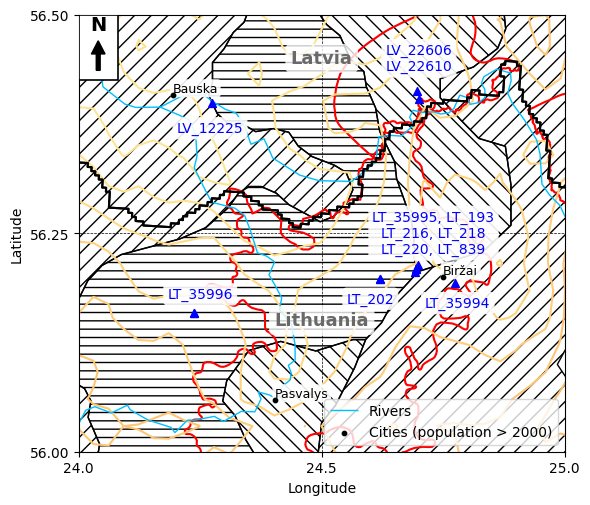

In [22]:
# ── Plot: Zoomed-in Map Only ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

# 1️⃣ Karst hatches
for entity, group in karst_region.groupby('EntityHand'):
    hatch = hatch_map.get(entity, None)
    if hatch:
        group.plot(ax=ax, facecolor='none', edgecolor='black', hatch=hatch, zorder=1)

# New lv_karst and lt_karst outlines (no fill)
lv_karst.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5, zorder=2)
lt_karst.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5, zorder=2)

# 2️⃣ Elevation points
elev.plot(ax=ax, column='Value', cmap='Spectral_r', norm=norm,
          markersize=18, linewidth=1.5, zorder=2)

# 3️⃣ Wells
gdf.plot(ax=ax, color='blue', marker='^', markersize=32, edgecolor=None, zorder=4)

label_positions = {
    "LT_35995, LT_193\nLT_216, LT_218\nLT_220, LT_839": (24.73, 56.25),
    "LT_202": (24.6, 56.175),
    "LT_35994": (24.78, 56.17),
    "LT_35996": (24.25, 56.18),
    "LV_12225": (24.27, 56.37),
    "LV_22606\nLV_22610": (24.7, 56.45),
}
for label, (x, y) in label_positions.items():
    ax.text(
        x, y, label,
        fontsize=10,  # bigger font
        color='blue',
        ha='center',
        va='center',
        zorder=5,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,  # semi-transparent background
            boxstyle='round,pad=0.3'
        )
    )

# 4️⃣ Country borders
countries.plot(ax=ax, color='black', edgecolor='black', zorder=3)
rivers.plot(ax=ax, color='deepskyblue', edgecolor=None, linewidth=1, label='Rivers')

population = 2000
cities_filtered = baltic_cities[
    (baltic_cities['country'].str.lower() != 'estonia') &
    (baltic_cities['population'] > population) &
    (baltic_cities['lng'] >= 24) & (baltic_cities['lng'] <= 25) &
    (baltic_cities['lat'] >= 56) & (baltic_cities['lat'] <= 56.5)
].copy()
cities_filtered.plot(ax=ax, color='black', markersize=10, label=f'Cities (population > {population})', zorder=5)

for x, y, label in zip(cities_filtered.geometry.x, cities_filtered.geometry.y, cities_filtered['city']):
    ax.text(
        x, y, label,
        fontsize=9,
        ha='left',
        va='bottom',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            boxstyle='round,pad=0.2'
        )
    )
# ── Countrylabels (manual positioning) ──────────────────────────────
label_positions = {
    "Lithuania": (24.5, 56.15),
    "Latvia": (24.5, 56.45),
}

for label, (x, y) in label_positions.items():
    ax.text(
        x, y, label,
        fontsize=13,
        weight='bold',
        color='dimgray',
        ha='center',
        va='center',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.8,
            boxstyle='round,pad=0.3'
        )
    )


# ── Add North Arrow (Upper Left Corner) ───────────────────────────────
add_north_arrow(ax, x=0, y=0.85, width=0.08, height=0.15)

# ── Add Accurate Scale Bar ──────────────────────────
# you can add scale bar, but keep in mind it would be distorted along the latitude
# add_scale_bar(ax, lat=56.03, lon_start=24.06, distance_km=15, segment_km=5, bar_height=0.008)

# ── Axes & Layout ──────────────────────────────────────────────────────────
ax.set_xlim(24, 25)
ax.set_ylim(56, 56.5)
ax.set_xticks([24, 24.5, 25])
ax.set_yticks([56, 56.25, 56.5])
# ax.set_title("Zoomed-in View: 56–56.5°N, 24–25°E")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle='--', linewidth=0.5, color='black')
ax.legend(frameon=True, loc='lower right')
plt.tight_layout()
plt.savefig('figures/zoomed_map.jpg', dpi=600, format='jpeg', bbox_inches='tight')
# plt.show()

### Europe Map

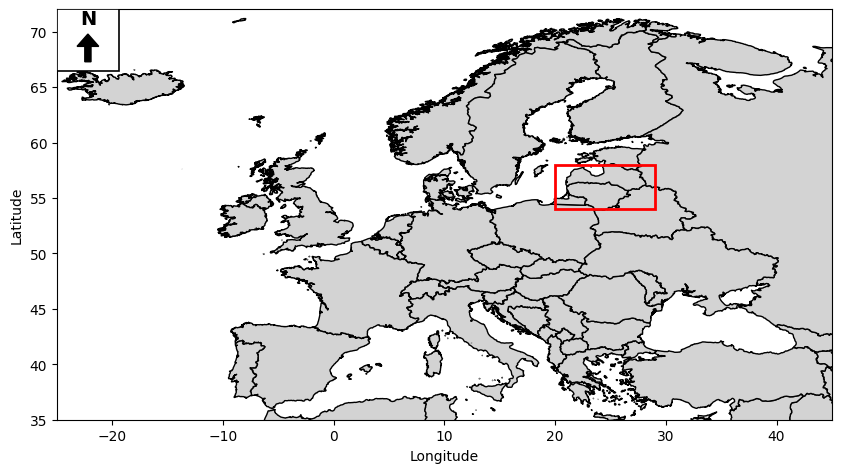

In [24]:
if world.crs != "EPSG:4326":
    world = world.to_crs(epsg=4326)

# Define approximate bounds for Europe (longitude and latitude)
europe_bounds = {
    "xmin": -25,  # Western edge
    "xmax": 45,   # Eastern edge
    "ymin": 35,   # Southern edge
    "ymax": 72    # Northern edge
}

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))

world.plot(ax=ax, color='lightgray', edgecolor='black')

# Set the x and y limits to focus on Europe
ax.set_xlim(europe_bounds["xmin"], europe_bounds["xmax"])
ax.set_ylim(europe_bounds["ymin"], europe_bounds["ymax"])

# ax.set_aspect(1.8)

rect = Rectangle((20, 54), 9, 4, linewidth=2, edgecolor='red', facecolor='none')

# ── Add North Arrow (Upper Left Corner) ───────────────────────────────
add_north_arrow(ax, x=0, y=0.85, width=0.08, height=0.15)

# ── Add Accurate Scale Bar ──────────────────────────
# you can add scale bar, but keep in mind it would be distorted along the latitude
# add_scale_bar(ax, lat=37, lon_start=20, distance_km=1000, segment_km=500, bar_height=0.4)

# Add the rectangle to the plot
ax.add_patch(rect)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.savefig('figures/europe_map.jpg', dpi=600, format='jpeg', bbox_inches='tight')

# Display the map
# plt.show()

### Map with Inset

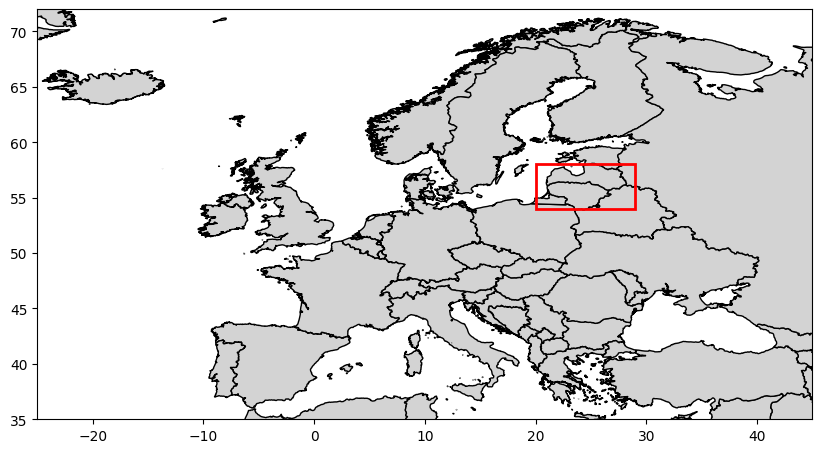

In [29]:
# Adjusted Europe map
if world.crs != "EPSG:4326":
    world = world.to_crs(epsg=4326)

# Define approximate bounds for Europe (longitude and latitude)
europe_bounds = {
    "xmin": -25,  # Western edge
    "xmax": 45,   # Eastern edge
    "ymin": 35,   # Southern edge
    "ymax": 72    # Northern edge
}

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))

world.plot(ax=ax, color='lightgray', edgecolor='black')

# Set the x and y limits to focus on Europe
ax.set_xlim(europe_bounds["xmin"], europe_bounds["xmax"])
ax.set_ylim(europe_bounds["ymin"], europe_bounds["ymax"])

# ax.set_aspect(1.8)

rect = Rectangle((20, 54), 9, 4, linewidth=2, edgecolor='red', facecolor='none')

# ── Add North Arrow (Upper Left Corner) ───────────────────────────────
# add_north_arrow(ax, x=0, y=0.85, width=0.08, height=0.15)

# ── Add Accurate Scale Bar ──────────────────────────
# you can add scale bar, but keep in mind it would be distorted along the latitude
# add_scale_bar(ax, lat=37, lon_start=20, distance_km=1000, segment_km=500, bar_height=0.4)

# Add the rectangle to the plot
ax.add_patch(rect)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

plt.savefig('figures/adj_europe_map.jpg', dpi=600, format='jpeg', bbox_inches='tight')

# Display the map
# plt.show()

In [42]:
# combine_maps.py (only the __main__ block changed)
if __name__ == "__main__":
    import sys

    p = argparse.ArgumentParser(description="Overlay the Europe map onto the main map.")
    p.add_argument("--main", default="figures/main_map.jpg", help="Path to main map")
    p.add_argument("--europe", default="figures/adj_europe_map.jpg", help="Path to Europe map")
    p.add_argument("--out", default="figures/combined_map.jpg", help="Output JPEG path")
    p.add_argument("--x", type=int, default=3300, help="X offset from top-left (pixels)")
    p.add_argument("--y", type=int, default=100, help="Y offset from top-left (pixels)")
    p.add_argument("--scale", type=float, default=0.30, help="Scale factor for Europe map (e.g., 0.8)")
    p.add_argument("--dpi", type=int, default=600, help="Output DPI metadata")
    p.add_argument("--quality", type=int, default=95, help="JPEG quality (1-95)")

    # If we're in a notebook (ipykernel/colab), ignore unknown args like "-f ..."
    in_notebook = any(k in sys.modules for k in ("ipykernel", "google.colab"))
    if in_notebook:
        args, _unknown = p.parse_known_args()
    else:
        args = p.parse_args()

    combine_maps(
        main_path=args.main,
        europe_path=args.europe,
        out_path=args.out,
        x=args.x,
        y=args.y,
        scale=args.scale,
        dpi=args.dpi,
        quality=args.quality,
    )


Saved: figures/combined_map.jpg (DPI=600, quality=95) at position (3250,100)
